# Predicting Urban Heat Islands: Greensburg
Greensburg is in the process of revamping the downtown area. After many businesses and locals slowly leaving the area, the city is hoping to revitalize a once booming community. Predicting Urban Heat Islands is could play an integral role in completing this goal. By locating warmer areas in the city, there is potential to implement protocols which have taken place in other cities such as the planting of more trees or improving open green space. 

Objective: Utilize the predictive model created for NYC using the data from Greensburg.

##### Packages

In [1]:
# Machine Learning
from sklearn.ensemble import RandomForestRegressor

# Feature Engineering
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Supress Warnings
import warnings
warnings.filterwarnings('ignore')

# Import Data Science Packages
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Import common GIS tools
import xarray as xr
import matplotlib.pyplot as plt
import rioxarray as rio
import rasterio
from matplotlib.cm import RdYlGn,jet,RdBu

# Geospatial raster data handling
import rioxarray as rxr

# Coordinate transformations
from pyproj import Proj, Transformer, CRS

# Others
import os
from tqdm import tqdm

# ckdTree for mapping 
from scipy.spatial import cKDTree

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

# Import Planetary Computer tools
import stackstac
import pystac_client
import planetary_computer 
from odc.stac import stac_load


# set the number of columns we see
pd.set_option('display.max_columns',None)

# Mapping Greensburg
Greensburg Pennsylvania is located about an hour from Pittsburgh, it is in the rolling hilly landscape of Western PA. 

The long/lat location of Greensburg is (40.27524, -79.57534, 40.34244, -79.52297).

We are going to use these proximity long/lat values to create a grid of location values. This will allow us to extract band values from the proximity of Greensburg, similar to NYC.

In [229]:
# let's createa 150 x 150 long/lat combination of data points

long_min,long_max,lat_min,lat_max = (-79.56,-79.53,40.29,40.315)
long = np.linspace(long_min,long_max,270)
lat = np.linspace(lat_min,lat_max,280)

longitudes,latitudes = np.meshgrid(long,lat)

greensburg_location_df = pd.DataFrame({'Longitude':longitudes.flatten(),'Latitude':latitudes.flatten()})

greensburg_location_df

,Longitude,Latitude
0,-79.560000,40.290
1,-79.559888,40.290
2,-79.559777,40.290
3,-79.559665,40.290
4,-79.559554,40.290
...,...,...
75595,-79.530446,40.315
75596,-79.530335,40.315
75597,-79.530223,40.315
75598,-79.530112,40.315


For each one long there is 150 lat points which is going to create 300 * 300 which is 90000 data points. 

This should allow for enough data so that we can find granular points but not so large that it is too complex to complete analysis on the satellite data.

# Satellite Imagery Creation
Satellite imagery was an essential component of this project, it allowed us to incorporate multiple satellite data to utilize computer vision techniques to make sense of the land that can be seen from above. This chapter is going to explore which satellites we used and for what reason.

Information about all satellites can be found here at the Microsoft Planetary Computer - https://planetarycomputer.microsoft.com/

- Sentinel 2 Satellite Data
- Sentinel 1 Satellite Data
- Landsat 8 Thermal Data
- Landsat 8 Non Thermal Data
- LiDar Elevation Data

##### Functions

In [202]:
# create a function that can collect satellite data
def create_xarray_data(location, date_range, satellite, cloud_coverage, bands, resolution):
    """ 
    Fetch Sentinel-2 imagery as an xarray dataset.

    Parameters:
    - location: Tuple (min_lon, min_lat, max_lon, max_lat) defining the bounding box.
    - date_range: String in 'YYYY-MM-DD/YYYY-MM-DD' format defining the time window.
    - satellite: Name of the satellite collection (e.g., 'sentinel-2-l2a').
    - cloud_coverage: Max cloud cover percentage (integer, e.g., 30 for <30% clouds).
    - bands: List of band names (e.g., ['B02', 'B03', 'B04'] for RGB).
    - resolution: Desired spatial resolution in meters (e.g., 10m for Sentinel-2).

    Returns:
    - xarray.Dataset containing the requested satellite data.
    """

    # Define bounding box
    # Connect to Microsoft Planetary Computer STAC API
    stac = pystac_client.Client.open("https://planetarycomputer.microsoft.com/api/stac/v1")


    # Search for matching satellite imagery
    search = stac.search(
        bbox=location, 
        datetime=date_range,
        collections=[satellite],
        query={"eo:cloud_cover": {"lt": cloud_coverage}},
    )

    # Convert search results to a list
    items = list(search.get_items())
    print(f'Satellite Images Found: {len(items)}')

    if not items:
        raise ValueError("No STAC items found for the given parameters.")

    # Sign the items for access
    signed_items = [planetary_computer.sign(item) for item in items]

    # Load data using stackstac
    data = stac_load(
        signed_items,
        bands=bands,
        crs="EPSG:4326",  # Latitude-Longitude
        resolution=resolution / 111320.0,  # Ensure resolution is in meters
        chunks={"x": 2048, "y": 2048},  # Optimize chunking
        dtype="uint16",
        patch_url=planetary_computer.sign,
        bbox=location
    )

    return data


In [203]:
def sentinel_1_xarray(location,date_range,satellite,bands):
    # Step 1: Connect to the Planetary Computer STAC API
    catalog_url = "https://planetarycomputer.microsoft.com/api/stac/v1"
    catalog = pystac_client.Client.open(catalog_url)

    search = catalog.search(
        collections=[satellite],  # Sentinel-1 GRD product
        bbox=location,
        datetime=date_range,
        limit=10
    )

    # Step 3: Retrieve the items
    items = list(search.items())
    print(f"Found {len(items)} Sentinel-1 scenes.")

    signed_items = [planetary_computer.sign(item).to_dict() for item in items]

        # Define the pixel resolution for the final product
    # Define the scale according to our selected crs, so we will use degrees
    resolution = 10  # meters per pixel 
    scale = resolution / 111320.0 # degrees per pixel for crs=4326 

    # 'items' is a list of STAC Items from a prior search (e.g., via pystac_client)
    sentinel_1_july_26th = stac_load(
        items,                           # STAC Items from Sentinel-1 GRD search
        bands=bands,             # Sentinel-1 polarization bands
        crs="EPSG:4326",                # Latitude-Longitude coordinate system
        resolution=scale,               # Degrees (set 'scale' to desired resolution, e.g., 0.0001 for ~10 m)
        chunks={"x": 2048, "y": 2048},  # Dask chunks for lazy loading
        dtype="uint16",                 # GRD data typically uint16 (check metadata if float32 needed)
        patch_url=planetary_computer.sign,  # Sign URLs for Planetary Computer access
        bbox=location                     # Bounding box in EPSG:4326 [min_lon, min_lat, max_lon, max_lat]
    )

    return sentinel_1_july_26th

In [204]:
import os

def output_file(filename, image_data, bounds, bands, location):
    """
    Saves a multi-band raster (GeoTIFF) from an xarray dataset.

    Parameters:
    - filename (str): Name of the output file (e.g., "output.tif").
    - image_data (xarray.DataArray or xarray.Dataset): The dataset containing band data.
    - bounds (tuple): Bounding box (min_lon, min_lat, max_lon, max_lat).
    - bands (list): List of band names to include in the output file.

    Returns:
    - None (Saves the GeoTIFF file)
    """

    filename = os.path.join(location, filename)
    
    # Extract width and height from dataset dimensions
    height = image_data.dims["latitude"]
    width = image_data.dims["longitude"]
    
    # Create raster transform using bounding box
    gt = rasterio.transform.from_bounds(bounds[0], bounds[1], bounds[2], bounds[3], width, height)

    # Assign CRS and transform to the dataset
    image_data.rio.write_crs("epsg:4326", inplace=True)
    image_data.rio.write_transform(transform=gt, inplace=True)

    # Create GeoTIFF output file
    with rasterio.open(filename, 'w', driver='GTiff', width=width, height=height,
                       crs='epsg:4326', transform=gt, count=len(bands),
                       compress='lzw', dtype='float64') as dst:
        for i, band in enumerate(bands):
            dst.write(image_data[band].values, i + 1)  # Ensure NumPy array format

    print(f"GeoTIFF saved: {filename}")

In [205]:
# function to create a median mosaic
def median_mosaic(data):
    median = data.median(dim='time').compute()
    return median

In [206]:
def create_lidar_data(satellite,location,date_range):
    client = pystac_client.Client.open(
        "https://planetarycomputer.microsoft.com/api/stac/v1/",
    )

    search = client.search(
        collections=[satellite],
        bbox=location,
        datetime=date_range
    )

    # Retrieve items
    items = {x.collection_id: x for x in search.get_all_items()}

    item = items[satellite]

    asset_key = 'data'

    signed_url = planetary_computer.sign(item.assets[asset_key].href)

    file = rxr.open_rasterio(signed_url)

    return file

In [207]:
from rasterio.transform import from_bounds

def lidar_file(filename, image_data, bounds, location):
    """
    Saves a single-band raster (GeoTIFF) from an xarray dataset.

    Parameters:
    - filename (str): Name of the output file (e.g., "output.tif").
    - image_data (xarray.DataArray): The dataset containing raster data.
    - bounds (tuple): Bounding box (min_lon, min_lat, max_lon, max_lat).
    - location (str): Directory where the file will be saved.

    Returns:
    - None (Saves the GeoTIFF file)
    """

    filename = os.path.join(location, filename)

    # Extract width and height from dataset dimensions
    time, height, width = image_data.shape  # (4097, 4097)
    
    # Create raster transform using bounding box
    transform = from_bounds(bounds[0], bounds[1], bounds[2], bounds[3], width, height)

    # Assign CRS and transform to the dataset
    image_data.rio.write_crs("epsg:4326", inplace=True)
    image_data.rio.write_transform(transform, inplace=True)

    # Save the dataset as a GeoTIFF
    with rasterio.open(filename, 'w', driver='GTiff', width=width, height=height,
                       count=1, crs='epsg:4326', transform=transform, dtype='float32',
                       compress='lzw') as dst:
        dst.write(image_data.values.squeeze(), 1)  # Write the single band

    print(f"GeoTIFF saved: {filename}")


## Greensburg Sentinel 2 Satellite Data
- Location - Greensburg
- Time Window - Winter 2024
- Satellite - Sentinel 2
- Cloud Coverage - <30%
- Bands - ("B01", "B02", "B03", "B04", "B05", "B06", "B07", "B08", "B8A", "B11", "B12")

Sentinel 2 satellite is a polar orbiting satellite and has a 5 day revisit time which allows time series data to be collect of the Earth. We are going to collect a series of images from the summer of 2021 to identify statistically average band values, this is done by taking a median mosaic.

### Winter 2024/2025
We are going to load in winter data to compare it to summer data to understand how different the landscapes can be and how this might impact UHI values.

In [233]:
greensburg_location = (-79.56,40.29,-79.53,40.315)
#nyc_location = (-74.00, 40.75, -73.87, 40.86) # Bounding box for NYC


winter_2024 = '2024-11-01/2025-03-01'
sentinel_2_satellite = "sentinel-2-l2a"    
cloud_coverage = 30
sentinel_2_bands = ["B01", "B02", "B03", "B04", "B05", "B06", "B07", "B08", "B8A", "B11", "B12"] 
resolution = 10

greensburg_sentinel_2_winters_2024_xarray = create_xarray_data(greensburg_location,winter_2024,sentinel_2_satellite,cloud_coverage,sentinel_2_bands,resolution)

Satellite Images Found: 10


In [234]:
greensburg_sentinel_2_winters_2024_xarray

<xarray.Dataset> Size: 21MB
Dimensions:      (latitude: 279, longitude: 335, time: 10)
Coordinates:
  * latitude     (latitude) float64 2kB 40.31 40.31 40.31 ... 40.29 40.29 40.29
  * longitude    (longitude) float64 3kB -79.56 -79.56 -79.56 ... -79.53 -79.53
    spatial_ref  int32 4B 4326
  * time         (time) datetime64[ns] 80B 2024-11-01T16:14:21.024000 ... 202...
Data variables:
    B01          (time, latitude, longitude) uint16 2MB dask.array<chunksize=(1, 279, 335), meta=np.ndarray>
    B02          (time, latitude, longitude) uint16 2MB dask.array<chunksize=(1, 279, 335), meta=np.ndarray>
    B03          (time, latitude, longitude) uint16 2MB dask.array<chunksize=(1, 279, 335), meta=np.ndarray>
    B04          (time, latitude, longitude) uint16 2MB dask.array<chunksize=(1, 279, 335), meta=np.ndarray>
    B05          (time, latitude, longitude) uint16 2MB dask.array<chunksize=(1, 279, 335), meta=np.ndarray>
    B06          (time, latitude, longitude) uint16 2MB dask.array<chunksize=(1, 279, 335), meta=np.ndarray>
    B07          (time, latitude, longitude) uint16 2MB dask.array<chunksize=(1, 279, 335), meta=np.ndarray>
    B08          (time, latitude, longitude) uint16 2MB dask.array<chunksize=(1, 279, 335), meta=np.ndarray>
    B8A          (time, latitude, longitude) uint16 2MB dask.array<chunksize=(1, 279, 335), meta=np.ndarray>
    B11          (time, latitude, longitude) uint16 2MB dask.array<chunksize=(1, 279, 335), meta=np.ndarray>
    B12          (time, latitude, longitude) uint16 2MB dask.array<chunksize=(1, 279, 335), meta=np.ndarray>

In [232]:
# get the median mosaic of sentinel 2 data
greensburg_sentinel_2_winters_2024 = median_mosaic(greensburg_sentinel_2_winters_2024_xarray) 

WarpOperationError: Chunk and warp failed

In [139]:
# output the sentinel 2 data as a tiff file
output_file('sentinel_2_winter.tiff',greensburg_sentinel_2_winters_2024,greensburg_location,sentinel_2_bands,'/Users/ben_nicholson/Documents/vs_code/urban_heat_islands/satellite_images/greensburg')

GeoTIFF saved: /Users/ben_nicholson/Documents/vs_code/urban_heat_islands/satellite_images/greensburg/sentinel_2_winter.tiff


### Summer 2024
Summer 2024 is going to be the data used in the model building stage as we are most interested in UHI values that take place when the temperature is hotter.

In [235]:
greensburg_location
summer_2024 = '2024-06-01/2024-09-01'
sentinel_2_satellite = "sentinel-2-l2a"    
cloud_coverage = 30
sentinel_2_bands = ["B01", "B02", "B03", "B04", "B05", "B06", "B07", "B08", "B8A", "B11", "B12"] 
resolution = 10

greensburg_sentinel_2_summer_2024_xarray = create_xarray_data(greensburg_location,summer_2024,sentinel_2_satellite,cloud_coverage,sentinel_2_bands,resolution)

Satellite Images Found: 10


In [236]:
# get the median mosaic of the sentinel 2 summer data in greensburg
greensburg_sentinel_2_summer_2024 = median_mosaic(greensburg_sentinel_2_summer_2024_xarray)

In [238]:
# output the file
output_file('sentinel_2_summer.tiff',greensburg_sentinel_2_summer_2024,greensburg_location,sentinel_2_bands,'/Users/ben_nicholson/Documents/vs_code/urban_heat_islands/satellite_images/greensburg')

GeoTIFF saved: /Users/ben_nicholson/Documents/vs_code/urban_heat_islands/satellite_images/greensburg/sentinel_2_summer.tiff


## Sentinel 1 Satellite Data
- Location - Greensburg
- Time Window - July 26th 2021
- Satellite - Sentinel 1
- Cloud Coverage - 10
- Sentinel 1 - (vv,vh)
- Resolution - 30

The sentinel 1 satellite is a part of the European Union Copernicus and is another satellite which is useful in tracking climate changes across the globe. We are going to be interested in two of their bands VV and VH which are used to capture bare soil in imagery.

In [239]:
greensburg_location
summer_2024
sentinel_1 = "sentinel-1-grd"                 # Sentinel-1 GRD
low_cloud_coverage = 0                        # Max 10% cloud cover
sentinel_1_all_bands = ['vv','vh']            # Sentinel 1 bands
resolution = 10                               # 10m resolution

greensburg_sentinel_1_summer_xarray = sentinel_1_xarray(greensburg_location,summer_2024,sentinel_1,sentinel_1_all_bands)

Found 6 Sentinel-1 scenes.


In [240]:
greensburg_sentinel_1_summer_2024 = median_mosaic(greensburg_sentinel_1_summer_xarray)

In [241]:
output_file('sentinel_1_summer.tiff',greensburg_sentinel_1_summer_2024,greensburg_location,sentinel_1_all_bands,'/Users/ben_nicholson/Documents/vs_code/urban_heat_islands/satellite_images/greensburg')

GeoTIFF saved: /Users/ben_nicholson/Documents/vs_code/urban_heat_islands/satellite_images/greensburg/sentinel_1_summer.tiff


## Landsat Thermal Data
For landsat data, this should be adjusted for the day that we want. Let's say that we want July 28th 2024. 

- Location - Greensburg
- Time Window - July 28th 2024
- Satellite - Landsat 8
- Cloud Coverage - 30
- Bands - (lwir11)
- Resolution - 30

The landsat 8 satellite is a sun-synchronous near polar orbit and specialzes in thermal infrared sennsors and operational land imager.

In [242]:
greensburg_location
july_31 = '2024-06-25/2024-06-30'
landsat = "landsat-c2-l2"
cloud_coverage = 30
thermal_bands = ['lwir11']
resolution = 10

greensburg_landsat_thermal_xarray = create_xarray_data(greensburg_location,july_31,landsat,cloud_coverage,thermal_bands,10)

Satellite Images Found: 1


In [243]:
greensburg_landsat_thermal = median_mosaic(greensburg_landsat_thermal_xarray)

In [244]:
# Scale Factors for the Surface Temperature band
scale2 = 0.00341802
offset2 = 149.0
kelvin_celsius = 273.15 # convert from Kelvin to Celsius
greensburg_landsat_thermal = greensburg_landsat_thermal.astype(float) * scale2 + offset2 - kelvin_celsius

In [245]:
output_file('landsat_thermal_july_28.tiff',greensburg_landsat_thermal,greensburg_location,thermal_bands,'/Users/ben_nicholson/Documents/vs_code/urban_heat_islands/satellite_images/greensburg')

GeoTIFF saved: /Users/ben_nicholson/Documents/vs_code/urban_heat_islands/satellite_images/greensburg/landsat_thermal_july_28.tiff


## Landsat Non Thermal Data

- Location - Greensburg
- Time Window - Summer 2024
- Satellite - Landsat 8
- Cloud Coverage - 30
- Bands - (red,green,blue,nir08)
- Resolution - 30

In [246]:
greensburg_location
summer_2024
landsat = "landsat-c2-l2"
cloud_coverage = 30
non_thermal_bands = ['red','green','blue','nir08']
resolution = 10

greensburg_landsat_non_thermal_summer_xarray = create_xarray_data(greensburg_location,summer_2024,landsat,cloud_coverage,non_thermal_bands,10)

Satellite Images Found: 7


In [247]:
greensburg_landsat_non_thermal_summer = median_mosaic(greensburg_landsat_non_thermal_summer_xarray)

In [248]:
# Scale Factors for the RGB and NIR bands
scale1 = 0.0000275
offset1 = -0.2
greensburg_landsat_non_thermal_summer[['red','blue','green','nir08']] = greensburg_landsat_non_thermal_summer[['red','blue','green','nir08']].astype(float) * scale1 + offset1

In [249]:
output_file('landsat_non_thermal_summer.tiff', greensburg_landsat_non_thermal_summer, greensburg_location, non_thermal_bands,'/Users/ben_nicholson/Documents/vs_code/urban_heat_islands/satellite_images/greensburg')

GeoTIFF saved: /Users/ben_nicholson/Documents/vs_code/urban_heat_islands/satellite_images/greensburg/landsat_non_thermal_summer.tiff


## Lidar Data
In the NYC model building we had access to the open source natural and building elevation for the Manhattan and Bronx area. However, as Greensburg is smaller there is less public data. We are on the lookout for Greensburg elevation data but in the meantime we are going to be using Lidar satellite for elevation data.

### Lidar Digital Terrian Model (DTM)
Provides the bare earth elevation without buildings or trees

In [250]:
greensburg_natural_elevation_dtm = create_lidar_data('3dep-lidar-dtm',greensburg_location,'2010-01-01/2024-01-01')

In [251]:
lidar_file('lidar_natural_elevation_dtm.tiff',greensburg_natural_elevation_dtm,greensburg_location,'/Users/ben_nicholson/Documents/vs_code/urban_heat_islands/satellite_images/greensburg')

GeoTIFF saved: /Users/ben_nicholson/Documents/vs_code/urban_heat_islands/satellite_images/greensburg/lidar_natural_elevation_dtm.tiff


### Lidar Height Above Ground (HAG)
Elevation of objects above the ground

In [252]:
greensburg_natural_elevation_hag = create_lidar_data('3dep-lidar-hag',greensburg_location,'2010-01-01/2024-01-01')

In [253]:
lidar_file('lidar_elevation_hag.tiff',greensburg_natural_elevation_hag,greensburg_location,'/Users/ben_nicholson/Documents/vs_code/urban_heat_islands/satellite_images/greensburg')

GeoTIFF saved: /Users/ben_nicholson/Documents/vs_code/urban_heat_islands/satellite_images/greensburg/lidar_elevation_hag.tiff


### Lidar Digital Surface Model (DSM)

In [254]:
greensburg_natural_elevation_dsm = create_lidar_data('3dep-lidar-dsm',greensburg_location,'2010-01-01/2024-01-01')

In [255]:
lidar_file('lidar_elevation_dsm.tiff',greensburg_natural_elevation_dsm,greensburg_location,'/Users/ben_nicholson/Documents/vs_code/urban_heat_islands/satellite_images/greensburg')

GeoTIFF saved: /Users/ben_nicholson/Documents/vs_code/urban_heat_islands/satellite_images/greensburg/lidar_elevation_dsm.tiff


# Load Satellite Imagery

##### Functions

In [256]:
def map_satellite_data(tiff_path,training_data, band_names):
    # Load the GeoTIFF data
    data = rxr.open_rasterio(tiff_path)
    tiff_crs = data.rio.crs

    # Read the CSV file
    latitudes = training_data['Latitude'].values
    longitudes = training_data['Longitude'].values

    # Convert lat/long to the GeoTIFF's CRS
    proj_wgs84 = Proj(init='epsg:4326')  
    proj_tiff = Proj(tiff_crs)
    transformer = Transformer.from_proj(proj_wgs84, proj_tiff)

    # Reproject coordinates
    transformed_coords = [transformer.transform(lat, lon) for lat, lon in zip(latitudes, longitudes)]
    xs, ys = zip(*transformed_coords)

    # Get available band numbers
    band_numbers = data.coords["band"].values
    
    # Validate that the user provided the correct number of band names
    if len(band_names) != len(band_numbers):
        raise ValueError(f"Expected {len(band_numbers)} band names, but got {len(band_names)}")

    # Dictionary to store extracted band values
    band_data = {band_name: [] for band_name in band_names}

    # Extract values for each band
    for x, y in tqdm(zip(xs, ys), total=len(xs), desc="Extracting band values"):
        for band, band_name in zip(band_numbers, band_names):
            value = data.sel(x=x, y=y, band=band, method="nearest").values
            band_data[band_name].append(value)

    # Convert dictionary to DataFrame
    return pd.DataFrame(band_data)

In [257]:
# Combine two datasets vertically (along columns) using pandas concat function.
def combine_two_datasets(dataset1,dataset2):
    '''
    Returns a  vertically concatenated dataset.
    Attributes:
    dataset1 - Dataset 1 to be combined 
    dataset2 - Dataset 2 to be combined
    '''
    
    data = pd.concat([dataset1,dataset2], axis=1)
    return data

In [ ]:
def add_nearest_data(uhi_data: pd.DataFrame, data_to_map: pd.DataFrame) -> pd.DataFrame:
    """
    Adds the nearest elevation value to the UHI dataset using a KDTree for fast nearest-neighbor search.
    
    Parameters:
        uhi_data (pd.DataFrame): DataFrame containing UHI data with 'Latitude' and 'Longitude' columns.
        elevation_data (pd.DataFrame): DataFrame containing elevation data with 'Latitude', 'Longitude', and 'z_grade' columns.

    Returns:
        pd.DataFrame: UHI dataset with an added 'Elevation' column.
    """
    # Extract coordinates from both datasets
    elevation_coords = np.array(list(zip(data_to_map["Latitude"], data_to_map["Longitude"])))
    uhi_coords = np.array(list(zip(uhi_data["Latitude"], uhi_data["Longitude"])))
    
    # Build KDTree for fast nearest-neighbor search
    tree = cKDTree(elevation_coords)
    
    # Find the nearest elevation point for each UHI point
    distances, indices = tree.query(uhi_coords)
    
    # Add the matched elevation values to the UHI dataset
    uhi_data = uhi_data.copy()

    for col in data_to_map.drop(columns=['Longitude','Latitude']):
        uhi_data[col] = data_to_map.iloc[indices][col].values
    
    return uhi_data

In [ ]:
def create_rounded_data(data):
    
    # convert the data to float values
    data = data.astype(float)

    # round by 3 decimal places
    data[['Longitude','Latitude']] = data[['Longitude','Latitude']].round(3)

    # group by the similar long/lat
    data = data.groupby(['Longitude','Latitude']).median().reset_index()

    return data

## Loading Sentinel 2

### Viewing Greensburg
We are going to compare the rgb of winter vs summer months to understand how important different months as vegetation can have a serious impact on the urban heats.

#### Greensburg Winter

In [258]:
greensburg_sentinel_2_winters_data = map_satellite_data('/Users/ben_nicholson/Documents/vs_code/urban_heat_islands/satellite_images/greensburg/sentinel_2_winter.tiff',greensburg_location_df,sentinel_2_bands)

Extracting band values: 100%|██████████| 75600/75600 [05:01<00:00, 251.01it/s]


In [259]:
greensburg_sentinel_2_winters_data.to_csv('/Users/ben_nicholson/Documents/vs_code/urban_heat_islands/greensburg_data/sentinel_2_data/sentinel_2_winters_data.csv')

In [260]:
greensburg_sentinel_2_winters_data = pd.read_csv('/Users/ben_nicholson/Documents/vs_code/urban_heat_islands/greensburg_data/sentinel_2_data/sentinel_2_winters_data.csv',index_col=0)

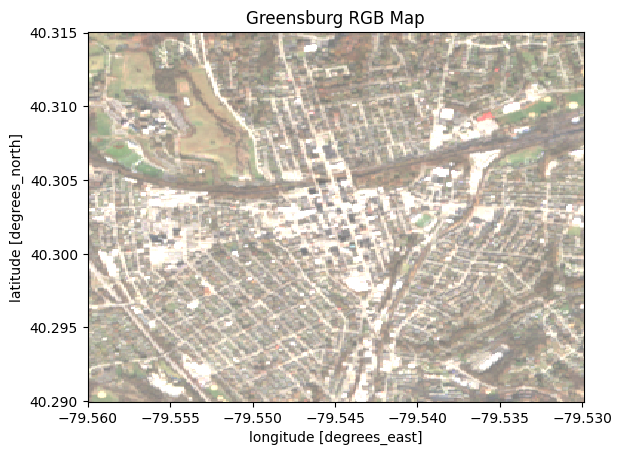

In [261]:
plot_data = greensburg_sentinel_2_winters_2024[['B04','B03','B02']].to_array()

plot_data.plot.imshow(vmin=0, vmax=2500)
plt.title('Greensburg RGB Map')
plt.show()

#### Greensburg Summer

In [262]:
greensburg_sentinel_2_summer_data = map_satellite_data('/Users/ben_nicholson/Documents/vs_code/urban_heat_islands/satellite_images/greensburg/sentinel_2_summer.tiff',greensburg_location_df,sentinel_2_bands)

Extracting band values: 100%|██████████| 75600/75600 [04:51<00:00, 259.14it/s]


In [263]:
greensburg_sentinel_2_summer_data.to_csv('/Users/ben_nicholson/Documents/vs_code/urban_heat_islands/greensburg_data/sentinel_2_data/sentinel_2_summer_data.csv')

In [264]:
greensburg_sentinel_2_summer_data = pd.read_csv('/Users/ben_nicholson/Documents/vs_code/urban_heat_islands/greensburg_data/sentinel_2_data/sentinel_2_summer_data.csv',index_col=0)

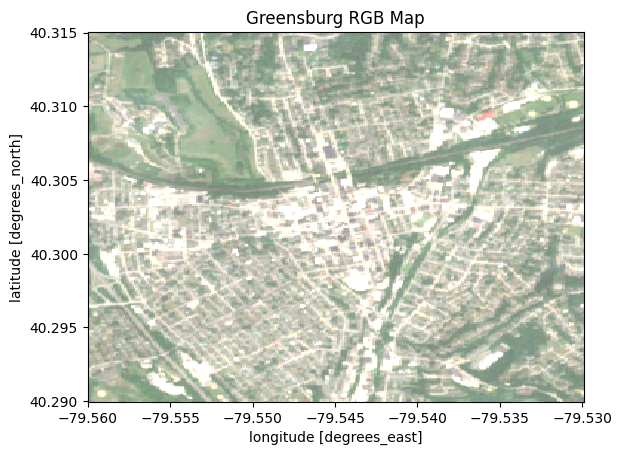

In [265]:
plot_data_summer = greensburg_sentinel_2_summer_2024[['B04','B03','B02']].to_array()

plot_data_summer.plot.imshow(vmin=0, vmax=2500)
plt.title('Greensburg RGB Map')
plt.show()

### Proximity Greensburg Sentinel 2 Data
Load in the sentinel 2 greensburg data so it can be used to train the model. We are going to extend the idea of proximity built in the NYC model.

In [266]:
greensburg_sentinel_2_rounded = create_rounded_data(combine_two_datasets(greensburg_location_df, greensburg_sentinel_2_summer_data)) 

greensburg_proximity_sentinel_2 = add_nearest_data(greensburg_location_df,greensburg_sentinel_2_rounded) 

greensburg_proximity_sentinel_2

,Longitude,Latitude,B01,B02,B03,B04,B05,B06,B07,B08,B8A,B11,B12
0,-79.560000,40.290,1523.5,1453.5,1653.5,1508.50,2087.0,3703.0,4312.0,4431.75,4589.5,3438.5,2324.5
1,-79.559888,40.290,1523.5,1453.5,1653.5,1508.50,2087.0,3703.0,4312.0,4431.75,4589.5,3438.5,2324.5
2,-79.559777,40.290,1523.5,1453.5,1653.5,1508.50,2087.0,3703.0,4312.0,4431.75,4589.5,3438.5,2324.5
3,-79.559665,40.290,1523.5,1453.5,1653.5,1508.50,2087.0,3703.0,4312.0,4431.75,4589.5,3438.5,2324.5
4,-79.559554,40.290,1523.5,1453.5,1653.5,1508.50,2087.0,3703.0,4312.0,4431.75,4589.5,3438.5,2324.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
75595,-79.530446,40.315,1596.5,1702.5,1810.5,1742.75,2164.5,3003.5,3386.5,3429.75,3553.5,2951.5,2337.5
75596,-79.530335,40.315,1596.5,1702.5,1810.5,1742.75,2164.5,3003.5,3386.5,3429.75,3553.5,2951.5,2337.5
75597,-79.530223,40.315,1596.5,1702.5,1810.5,1742.75,2164.5,3003.5,3386.5,3429.75,3553.5,2951.5,2337.5
75598,-79.530112,40.315,1596.5,1702.5,1810.5,1742.75,2164.5,3003.5,3386.5,3429.75,3553.5,2951.5,2337.5


This an example of why different seasons require a different training model as you can see just how different the values are.

## Greensburg Sentinel 1 Data

In [267]:
# create sentinel 1 data
greensburg_sentinel_1_summer_data = map_satellite_data('/Users/ben_nicholson/Documents/vs_code/urban_heat_islands/satellite_images/greensburg/sentinel_1_summer.tiff',greensburg_location_df,sentinel_1_all_bands)

greensburg_sentinel_1_summer_data = combine_two_datasets(greensburg_location_df,greensburg_sentinel_1_summer_data)

Extracting band values: 100%|██████████| 75600/75600 [00:49<00:00, 1531.93it/s]


### Proximity Sentinel 1 Data

In [268]:
greensburg_sentinel_1_rounded = create_rounded_data(greensburg_sentinel_1_summer_data) 

greensburg_sentinel_1_rounded_mapped = add_nearest_data(greensburg_location_df,greensburg_sentinel_1_rounded)

greensburg_sentinel_1_rounded_mapped

,Longitude,Latitude,vv,vh
0,-79.560000,40.290,200.75,88.75
1,-79.559888,40.290,200.75,88.75
2,-79.559777,40.290,200.75,88.75
3,-79.559665,40.290,200.75,88.75
4,-79.559554,40.290,200.75,88.75
...,...,...,...,...
75595,-79.530446,40.315,179.00,90.00
75596,-79.530335,40.315,179.00,90.00
75597,-79.530223,40.315,179.00,90.00
75598,-79.530112,40.315,179.00,90.00


## Loading Landsat Data

In [269]:
greensburg_landsat_thermal_data = map_satellite_data('/Users/ben_nicholson/Documents/vs_code/urban_heat_islands/satellite_images/greensburg/landsat_thermal_july_28.tiff',greensburg_location_df,thermal_bands)

Extracting band values: 100%|██████████| 75600/75600 [00:23<00:00, 3188.73it/s]


In [270]:
greensburg_landsat_thermal_data = combine_two_datasets(greensburg_location_df,greensburg_landsat_thermal_data) 

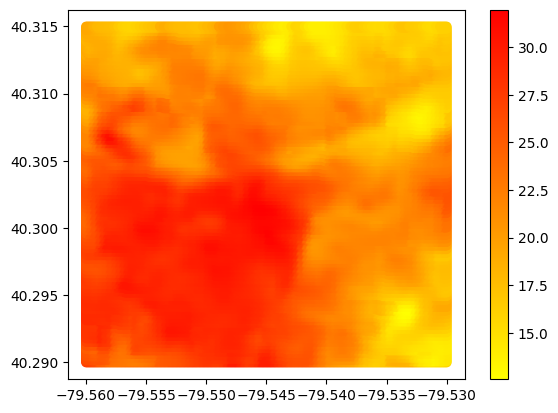

In [271]:
plt.scatter(greensburg_landsat_thermal_data['Longitude'],greensburg_landsat_thermal_data['Latitude'],c=greensburg_landsat_thermal_data['lwir11'],cmap='autumn_r') 
plt.colorbar()

## Non Landsat Data

In [272]:
greensburg_non_thermal_data = map_satellite_data('/Users/ben_nicholson/Documents/vs_code/urban_heat_islands/satellite_images/greensburg/landsat_non_thermal_summer.tiff',greensburg_location_df,non_thermal_bands)

greensburg_non_thermal_data = combine_two_datasets(greensburg_location_df,greensburg_non_thermal_data) 

Extracting band values: 100%|██████████| 75600/75600 [01:42<00:00, 741.17it/s]


In [273]:
greensburg_non_thermal_data_rounded = create_rounded_data(greensburg_non_thermal_data)

greensburg_non_thermal_data_mapped = add_nearest_data(greensburg_location_df,greensburg_non_thermal_data_rounded)

## Lidar Elevation

### Natural Elevation DTM
What it represents: The bare ground surface, with all objects removed (like trees and buildings).

Use case: Useful for studying topography, hydrology, or anything where surface elevation matters.

How it’s created: Uses last returns or filtered data to exclude non-ground points.

#### Granular

In [274]:
greensburg_natural_elevation_dtm = map_satellite_data('/Users/ben_nicholson/Documents/vs_code/urban_heat_islands/satellite_images/greensburg/lidar_natural_elevation_dtm.tiff',greensburg_location_df,['elevation'])

greensburg_natural_elevation_dtm = combine_two_datasets(greensburg_location_df, greensburg_natural_elevation_dtm) 

Extracting band values: 100%|██████████| 75600/75600 [00:26<00:00, 2883.05it/s]


In [275]:
# remove the very low values where data was not recorded

greensburg_natural_elevation_dtm = greensburg_natural_elevation_dtm[(greensburg_natural_elevation_dtm['elevation']>0)]

greensburg_natural_elevation_dtm

,Longitude,Latitude,elevation
0,-79.560000,40.290,378.84
1,-79.559888,40.290,378.02
2,-79.559777,40.290,377.18
3,-79.559665,40.290,376.42
4,-79.559554,40.290,375.94
...,...,...,...
75595,-79.530446,40.315,419.24588
75596,-79.530335,40.315,420.62253
75597,-79.530223,40.315,421.01135
75598,-79.530112,40.315,423.24707


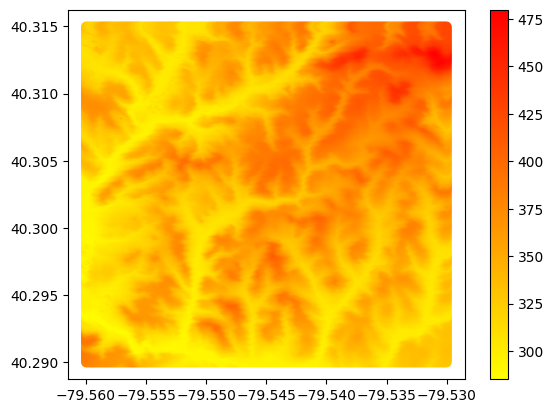

In [276]:
plt.scatter(greensburg_natural_elevation_dtm['Longitude'],greensburg_natural_elevation_dtm['Latitude'],c=greensburg_natural_elevation_dtm['elevation'],cmap='autumn_r')
plt.colorbar()

#### Proximity

In [277]:
greensburg_natural_elevation_dtm_rounded = create_rounded_data(greensburg_natural_elevation_dtm)

greensburg_natural_elevation_dtm_mapped = add_nearest_data(greensburg_location_df,greensburg_natural_elevation_dtm_rounded)

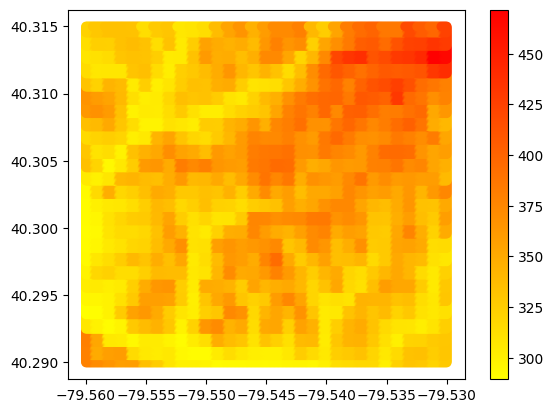

In [278]:
plt.scatter(greensburg_natural_elevation_dtm_mapped['Longitude'],greensburg_natural_elevation_dtm_mapped['Latitude'],c=greensburg_natural_elevation_dtm_mapped['elevation'],cmap='autumn_r')
plt.colorbar()

### Natural Elevation (DSM)

What it represents: The earth’s surface including all objects on it — buildings, trees, vehicles, etc.

Use case: Great for modeling what a drone or satellite would "see" from above.

How it’s created: Derived from the first returns of LiDAR pulses (hits the tops of objects).


#### Granular Elevation

In [279]:
greensburg_elevation_dsm = map_satellite_data('/Users/ben_nicholson/Documents/vs_code/urban_heat_islands/satellite_images/greensburg/lidar_elevation_dsm.tiff',greensburg_location_df,['elevation'])

greensburg_elevation_dsm = combine_two_datasets(greensburg_location_df,greensburg_elevation_dsm)

Extracting band values: 100%|██████████| 75600/75600 [00:25<00:00, 2927.33it/s]


In [280]:
greensburg_elevation_dsm = greensburg_elevation_dsm[greensburg_elevation_dsm['elevation'] > 0]

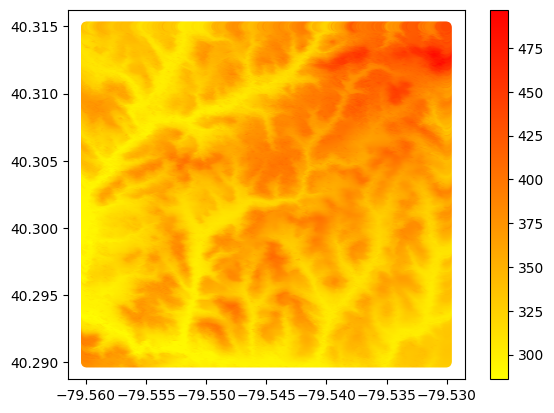

In [281]:
plt.scatter(greensburg_elevation_dsm['Longitude'],greensburg_elevation_dsm['Latitude'],c=greensburg_elevation_dsm['elevation'],cmap='autumn_r')
plt.colorbar()

In [282]:
greensburg_elevation_dsm_mapped = add_nearest_data(greensburg_location_df,create_rounded_data(greensburg_elevation_dsm)) 

### Lidar Hag
The height of objects above the ground (e.g., tree height, building height).

Use case: Critical for forestry, urban planning, or object detection (e.g., estimating tree biomass).

#### Granular Elevation

In [283]:
greensburg_elevation_hag = map_satellite_data('/Users/ben_nicholson/Documents/vs_code/urban_heat_islands/satellite_images/greensburg/lidar_elevation_hag.tiff',greensburg_location_df,['elevation'])

greensburg_elevation_hag = combine_two_datasets(greensburg_location_df,greensburg_elevation_hag)

Extracting band values: 100%|██████████| 75600/75600 [00:24<00:00, 3123.41it/s]


In [284]:
greensburg_elevation_hag = greensburg_elevation_hag[greensburg_elevation_hag['elevation'] > 0]

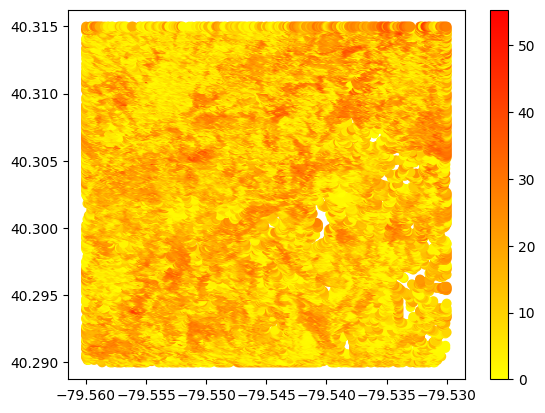

In [285]:
plt.scatter(greensburg_elevation_hag['Longitude'],greensburg_elevation_hag['Latitude'],c=greensburg_elevation_hag['elevation'],cmap='autumn_r')
plt.colorbar()

#### Proximity Elevation

In [286]:
greensburg_elevation_hag_rounded = create_rounded_data(greensburg_elevation_hag) 

greensburg_elevation_hag_mapped = add_nearest_data(greensburg_location_df,greensburg_elevation_hag_rounded)

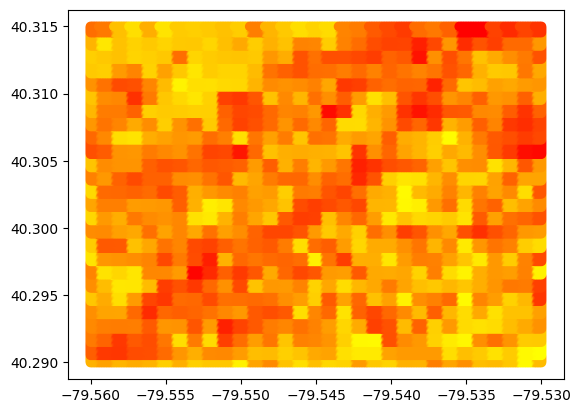

In [287]:
plt.scatter(greensburg_elevation_hag_mapped['Longitude'],greensburg_elevation_hag_mapped['Latitude'],c=greensburg_elevation_hag_mapped['elevation'],cmap='autumn_r')

# Model Building for Greensburg
We are going to use the NYC urban heat island temperatures to train the model for Greensburg. It is going to be different to the original NYC model as we are using satellite data rather than open source data.

## NYC Model Building

### Load Data

In [288]:
# load in the uhi train data to be used as the training data
uhi_train = pd.read_csv('/Users/ben_nicholson/Documents/vs_code/urban_heat_islands/ey_dataset/Training_data_uhi_index_2025-02-18.csv')

uhi_train

,Longitude,Latitude,datetime,UHI Index
0,-73.909167,40.813107,24-07-2021 15:53,1.030289
1,-73.909187,40.813045,24-07-2021 15:53,1.030289
2,-73.909215,40.812978,24-07-2021 15:53,1.023798
3,-73.909242,40.812908,24-07-2021 15:53,1.023798
4,-73.909257,40.812845,24-07-2021 15:53,1.021634
...,...,...,...,...
11224,-73.957050,40.790333,24-07-2021 15:57,0.972470
11225,-73.957063,40.790308,24-07-2021 15:57,0.972470
11226,-73.957093,40.790270,24-07-2021 15:57,0.981124
11227,-73.957112,40.790253,24-07-2021 15:59,0.981245


In [289]:
nyc_location = (-74.00, 40.75, -73.87, 40.86)

### Satellite Imagery Creation

### Lidar Elevation
- DSM: Total Elevation
- DTM: Natural Elevation
- HAG: Building Height Only

#### DSM: Total Elevation

In [290]:
nyc_dsm_elevation = create_lidar_data('3dep-lidar-dsm',nyc_location,'2010-01-01/2024-01-01')

In [291]:
lidar_file('lidar_elevation_dsm_nyc.tiff',nyc_dsm_elevation,nyc_location,'/Users/ben_nicholson/Documents/vs_code/urban_heat_islands/satellite_images/greensburg')

GeoTIFF saved: /Users/ben_nicholson/Documents/vs_code/urban_heat_islands/satellite_images/greensburg/lidar_elevation_dsm_nyc.tiff


#### DTM: Natural Elevation

In [292]:
nyc_dtm_natural_elevation = create_lidar_data('3dep-lidar-dtm',nyc_location,'2010-01-01/2024-01-01')

In [293]:
lidar_file('lidar_elevation_dtm_nyc.tiff',nyc_dtm_natural_elevation,nyc_location,'/Users/ben_nicholson/Documents/vs_code/urban_heat_islands/satellite_images/greensburg')

GeoTIFF saved: /Users/ben_nicholson/Documents/vs_code/urban_heat_islands/satellite_images/greensburg/lidar_elevation_dtm_nyc.tiff


#### HAG: Building Height Only

In [294]:
nyc_hag_building_elevation = create_lidar_data('3dep-lidar-hag',nyc_location,'2010-01-01/2024-01-01')

In [295]:
lidar_file('lidar_elevation_hag_nyc.tiff',nyc_hag_building_elevation,nyc_location,'/Users/ben_nicholson/Documents/vs_code/urban_heat_islands/satellite_images/greensburg')

GeoTIFF saved: /Users/ben_nicholson/Documents/vs_code/urban_heat_islands/satellite_images/greensburg/lidar_elevation_hag_nyc.tiff


### Satellite Imagery Loading

#### Sentinel 2

In [296]:
nyc_sentinel_2_proximity_data = pd.read_csv('/Users/ben_nicholson/Documents/vs_code/urban_heat_islands/created_data/satellite_data/sentinel_2_proximity_data.csv',index_col=0)

nyc_sentinel_2_proximity_data

,Longitude,Latitude,B01,B02,B03,B04,B05,B06,B07,B08,B8A,B11,B12
0,-73.995,40.771,1112.0,1761.0,1983.0,2101.0,1991.00,1993.50,2096.5,2198.0,2077.50,2048.0,1881.00
1,-73.995,40.772,1112.0,1418.0,1595.0,1721.5,1680.00,1720.00,1744.0,1765.5,1741.50,1841.0,1732.50
2,-73.994,40.771,1392.5,1409.0,1558.0,1782.0,1922.50,1872.50,1915.0,1922.0,1936.00,2080.5,1942.50
3,-73.994,40.772,1365.0,1411.0,1554.0,1674.0,1772.00,1817.00,1858.0,1725.0,1792.50,1904.5,1786.00
4,-73.994,40.773,1275.0,1359.5,1507.0,1617.5,1801.75,1736.25,1807.0,1757.0,1852.50,1861.0,1638.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1497,-73.880,40.808,1661.5,1391.0,1492.0,1589.0,1946.50,1994.00,1940.5,1690.0,1957.50,2306.0,2174.00
1498,-73.880,40.809,1202.5,1587.0,1719.0,1867.0,1946.00,1993.50,1954.0,1912.0,1955.00,2135.5,1963.50
1499,-73.880,40.810,1088.0,862.0,959.0,995.0,1315.00,1490.00,1583.0,1554.0,1569.50,1603.5,1501.50
1500,-73.879,40.806,956.0,1087.0,1196.0,1231.0,1340.00,1550.00,1628.0,1421.0,1615.50,1679.0,1428.00


In [297]:
nyc_sentinel_2_proximity_uhi_train = add_nearest_data(uhi_train,nyc_sentinel_2_proximity_data)

nyc_sentinel_2_proximity_uhi_train

,Longitude,Latitude,datetime,UHI Index,B01,B02,B03,B04,B05,B06,B07,B08,B8A,B11,B12
0,-73.909167,40.813107,24-07-2021 15:53,1.030289,841.5,675.0,823.0,821.5,1212.0,1883.0,2117.5,2181.5,2251.0,1617.5,1305.5
1,-73.909187,40.813045,24-07-2021 15:53,1.030289,841.5,675.0,823.0,821.5,1212.0,1883.0,2117.5,2181.5,2251.0,1617.5,1305.5
2,-73.909215,40.812978,24-07-2021 15:53,1.023798,841.5,675.0,823.0,821.5,1212.0,1883.0,2117.5,2181.5,2251.0,1617.5,1305.5
3,-73.909242,40.812908,24-07-2021 15:53,1.023798,841.5,675.0,823.0,821.5,1212.0,1883.0,2117.5,2181.5,2251.0,1617.5,1305.5
4,-73.909257,40.812845,24-07-2021 15:53,1.021634,841.5,675.0,823.0,821.5,1212.0,1883.0,2117.5,2181.5,2251.0,1617.5,1305.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11224,-73.957050,40.790333,24-07-2021 15:57,0.972470,462.5,506.5,725.5,501.0,999.0,2612.0,3111.5,3489.0,3446.5,1925.0,1072.5
11225,-73.957063,40.790308,24-07-2021 15:57,0.972470,462.5,506.5,725.5,501.0,999.0,2612.0,3111.5,3489.0,3446.5,1925.0,1072.5
11226,-73.957093,40.790270,24-07-2021 15:57,0.981124,462.5,506.5,725.5,501.0,999.0,2612.0,3111.5,3489.0,3446.5,1925.0,1072.5
11227,-73.957112,40.790253,24-07-2021 15:59,0.981245,462.5,506.5,725.5,501.0,999.0,2612.0,3111.5,3489.0,3446.5,1925.0,1072.5


#### Sentinel 1

In [298]:
nyc_sentinel_1_proximity_data = pd.read_csv('/Users/ben_nicholson/Documents/vs_code/urban_heat_islands/created_data/satellite_data/sentinel_1_proximity_data.csv',index_col=0)

nyc_sentinel_1_proximity_uhi_train = add_nearest_data(uhi_train,nyc_sentinel_1_proximity_data)

nyc_sentinel_1_proximity_uhi_train

,Longitude,Latitude,datetime,UHI Index,vv,vh
0,-73.909167,40.813107,24-07-2021 15:53,1.030289,364.0,194.0
1,-73.909187,40.813045,24-07-2021 15:53,1.030289,364.0,194.0
2,-73.909215,40.812978,24-07-2021 15:53,1.023798,364.0,194.0
3,-73.909242,40.812908,24-07-2021 15:53,1.023798,364.0,194.0
4,-73.909257,40.812845,24-07-2021 15:53,1.021634,364.0,194.0
...,...,...,...,...,...,...
11224,-73.957050,40.790333,24-07-2021 15:57,0.972470,214.5,106.5
11225,-73.957063,40.790308,24-07-2021 15:57,0.972470,214.5,106.5
11226,-73.957093,40.790270,24-07-2021 15:57,0.981124,214.5,106.5
11227,-73.957112,40.790253,24-07-2021 15:59,0.981245,214.5,106.5


#### Landsat Thermal

In [299]:
nyc_landsat_thermal = pd.read_csv('/Users/ben_nicholson/Documents/vs_code/urban_heat_islands/created_data/satellite_data/landsat_8_granular_data.csv',index_col=0)

nyc_landsat_thermal

,Longitude,Latitude,datetime,UHI Index,lwir11
0,-73.909167,40.813107,24-07-2021 15:53,1.030289,37.091675
1,-73.909187,40.813045,24-07-2021 15:53,1.030289,37.091675
2,-73.909215,40.812978,24-07-2021 15:53,1.023798,37.091675
3,-73.909242,40.812908,24-07-2021 15:53,1.023798,37.091675
4,-73.909257,40.812845,24-07-2021 15:53,1.021634,36.760128
...,...,...,...,...,...
11224,-73.957050,40.790333,24-07-2021 15:57,0.972470,29.951432
11225,-73.957063,40.790308,24-07-2021 15:57,0.972470,30.033464
11226,-73.957093,40.790270,24-07-2021 15:57,0.981124,30.033464
11227,-73.957112,40.790253,24-07-2021 15:59,0.981245,30.033464


#### Landsat non thermal

In [300]:
nyc_landsat_non_thermal = pd.read_csv('/Users/ben_nicholson/Documents/vs_code/urban_heat_islands/created_data/satellite_data/landsat_8_non_thermal_proximity_data.csv',index_col=0)

nyc_landsat_non_thermal_uhi_train = add_nearest_data(uhi_train, nyc_landsat_non_thermal)

nyc_landsat_non_thermal_uhi_train

,Longitude,Latitude,datetime,UHI Index,red,blue,green,nir08
0,-73.909167,40.813107,24-07-2021 15:53,1.030289,0.089685,0.070380,0.089712,0.209558
1,-73.909187,40.813045,24-07-2021 15:53,1.030289,0.089685,0.070380,0.089712,0.209558
2,-73.909215,40.812978,24-07-2021 15:53,1.023798,0.089685,0.070380,0.089712,0.209558
3,-73.909242,40.812908,24-07-2021 15:53,1.023798,0.089685,0.070380,0.089712,0.209558
4,-73.909257,40.812845,24-07-2021 15:53,1.021634,0.089685,0.070380,0.089712,0.209558
...,...,...,...,...,...,...,...,...
11224,-73.957050,40.790333,24-07-2021 15:57,0.972470,0.041821,0.039044,0.056506,0.320987
11225,-73.957063,40.790308,24-07-2021 15:57,0.972470,0.041821,0.039044,0.056506,0.320987
11226,-73.957093,40.790270,24-07-2021 15:57,0.981124,0.041821,0.039044,0.056506,0.320987
11227,-73.957112,40.790253,24-07-2021 15:59,0.981245,0.041821,0.039044,0.056506,0.320987


#### DSM Lidar Elevation: Total Elevation

In [301]:
# let's create a funciton that creates random noise for a single point
def generate_noise(long,lat,proximity_points,std=0.0001):
    lat_noisy = lat + np.random.normal(0,std,proximity_points)
    long_noisy = long + np.random.normal(0,std,proximity_points)

    return list(zip(long_noisy, lat_noisy))

In [302]:
sentinel_long_noisy = []
sentinel_lat_noisy = []

for _,row in uhi_train.iterrows():
    long = row['Longitude']
    lat = row['Latitude']

    noise = generate_noise(long,lat,5)
    for i,row in enumerate(noise):
        sentinel_long_noisy.append(noise[i][0])
        sentinel_lat_noisy.append(noise[i][1])


# create a new df
proximity_uhi_train = pd.DataFrame({'Longitude':sentinel_long_noisy,'Latitude':sentinel_lat_noisy})

proximity_uhi_train

,Longitude,Latitude
0,-73.909071,40.813051
1,-73.909108,40.813128
2,-73.909118,40.813047
3,-73.909304,40.813043
4,-73.909116,40.813127
...,...,...
56140,-73.957144,40.790252
56141,-73.957067,40.790258
56142,-73.957067,40.790242
56143,-73.957089,40.790154


In [303]:
nyc_dsm_elevation = map_satellite_data('/Users/ben_nicholson/Documents/vs_code/urban_heat_islands/satellite_images/greensburg/lidar_elevation_dsm_nyc.tiff',proximity_uhi_train,['dsm_elevation'])

Extracting band values: 100%|██████████| 56145/56145 [00:19<00:00, 2846.23it/s]


In [304]:
nyc_dsm_elevation = combine_two_datasets(proximity_uhi_train,nyc_dsm_elevation) 

nyc_dsm_elevation = nyc_dsm_elevation[nyc_dsm_elevation['dsm_elevation'] > 0]

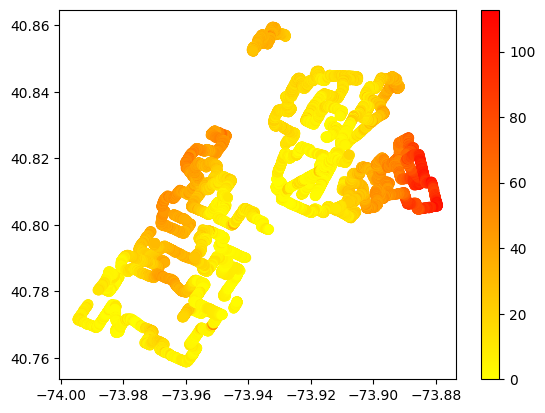

In [305]:
plt.scatter(nyc_dsm_elevation['Longitude'],nyc_dsm_elevation['Latitude'],c=nyc_dsm_elevation['dsm_elevation'],cmap='autumn_r') 
plt.colorbar()

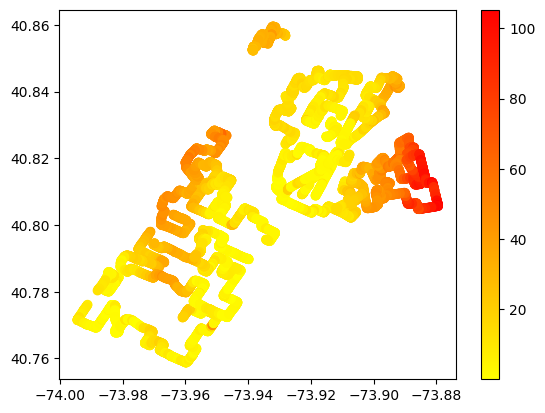

In [306]:
nyc_dsm_elevation_uhi_train = add_nearest_data(uhi_train,create_rounded_data(nyc_dsm_elevation))

plt.scatter(nyc_dsm_elevation_uhi_train['Longitude'],nyc_dsm_elevation_uhi_train['Latitude'],c=nyc_dsm_elevation_uhi_train['dsm_elevation'],cmap='autumn_r') 
plt.colorbar()

##### DTM Lidar Elevation: Natural Elevation

In [307]:
nyc_dtm_elevation = map_satellite_data('/Users/ben_nicholson/Documents/vs_code/urban_heat_islands/satellite_images/greensburg/lidar_elevation_dtm_nyc.tiff',proximity_uhi_train,['dtm_elevation'])

Extracting band values: 100%|██████████| 56145/56145 [00:19<00:00, 2829.10it/s]


In [308]:
nyc_dtm_elevation = combine_two_datasets(proximity_uhi_train,nyc_dtm_elevation) 

nyc_dtm_elevation = nyc_dtm_elevation[nyc_dtm_elevation['dtm_elevation'] > 0]

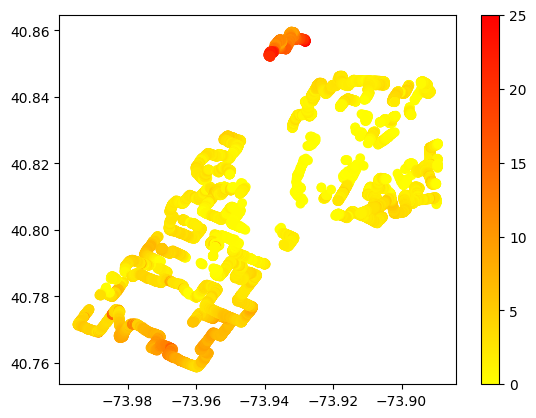

In [309]:
plt.scatter(nyc_dtm_elevation['Longitude'],nyc_dtm_elevation['Latitude'],c=nyc_dtm_elevation['dtm_elevation'],cmap='autumn_r') 
plt.colorbar()

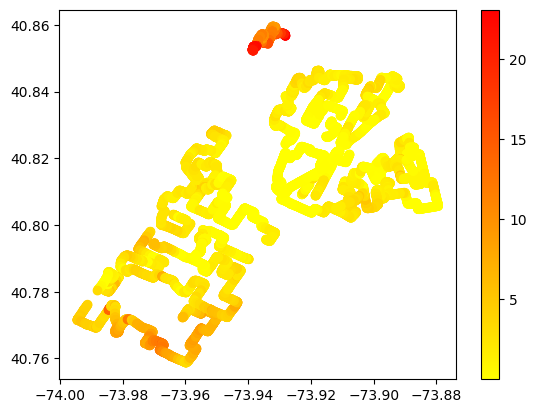

In [310]:
nyc_dtm_elevation_uhi_train = add_nearest_data(uhi_train,create_rounded_data(nyc_dtm_elevation))

plt.scatter(nyc_dtm_elevation_uhi_train['Longitude'],nyc_dtm_elevation_uhi_train['Latitude'],c=nyc_dtm_elevation_uhi_train['dtm_elevation'],cmap='autumn_r') 
plt.colorbar()

##### Hag Lidar Elevation: uilding Height Only

In [311]:
nyc_hag_elevation = map_satellite_data('/Users/ben_nicholson/Documents/vs_code/urban_heat_islands/satellite_images/greensburg/lidar_elevation_hag_nyc.tiff',proximity_uhi_train,['hag_elevation'])

Extracting band values: 100%|██████████| 56145/56145 [00:18<00:00, 3027.55it/s]


In [312]:
nyc_hag_elevation = combine_two_datasets(proximity_uhi_train,nyc_hag_elevation) 

nyc_hag_elevation = nyc_hag_elevation[nyc_hag_elevation['hag_elevation'] > 0]

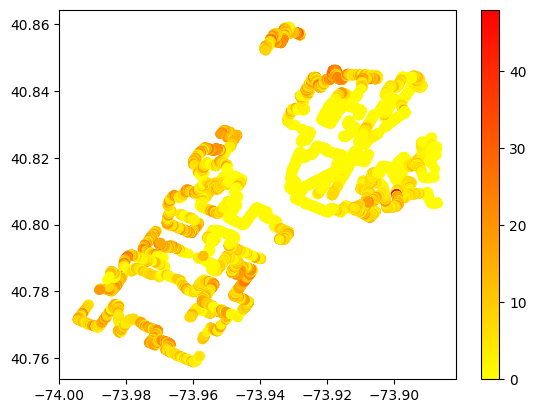

In [313]:
plt.scatter(nyc_hag_elevation['Longitude'],nyc_hag_elevation['Latitude'],c=nyc_hag_elevation['hag_elevation'],cmap='autumn_r') 
plt.colorbar()

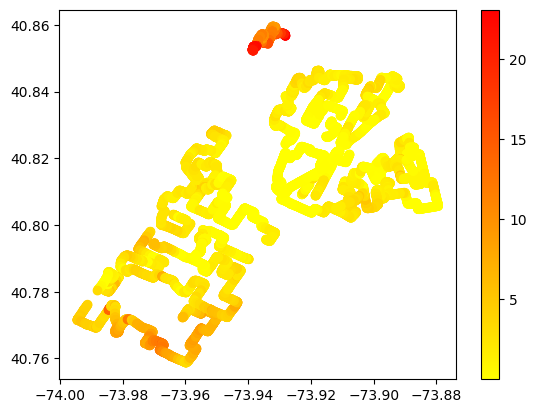

In [314]:
nyc_hag_elevation_uhi_train = add_nearest_data(uhi_train,create_rounded_data(nyc_hag_elevation))

plt.scatter(nyc_hag_elevation_uhi_train['Longitude'],nyc_hag_elevation_uhi_train['Latitude'],c=nyc_dtm_elevation_uhi_train['dtm_elevation'],cmap='autumn_r') 
plt.colorbar()

## Build NYC Model
- Sentinel 2
- Sentinel 1
- Landsat Thermal
- Landsat Non Thermal
- Lidar dsm
- Lidar dtm
- Lidar HAG

In [315]:
nyc_X = pd.DataFrame()

nyc_X[sentinel_2_bands] = nyc_sentinel_2_proximity_uhi_train[sentinel_2_bands]
nyc_X[sentinel_1_all_bands] = nyc_sentinel_1_proximity_uhi_train[sentinel_1_all_bands]
nyc_X[thermal_bands] = nyc_landsat_thermal[thermal_bands]
nyc_X[non_thermal_bands] = nyc_landsat_non_thermal_uhi_train[non_thermal_bands]
nyc_X['dsm elevation'] = nyc_dsm_elevation_uhi_train['dsm_elevation']
nyc_X['dtm elevation'] = nyc_dtm_elevation_uhi_train['dtm_elevation']
nyc_X['hag elevation'] = nyc_hag_elevation_uhi_train['hag_elevation']

In [316]:
nyc_X

,B01,B02,B03,B04,B05,B06,B07,B08,B8A,B11,B12,vv,vh,lwir11,red,green,blue,nir08,dsm elevation,dtm elevation,hag elevation
0,841.5,675.0,823.0,821.5,1212.0,1883.0,2117.5,2181.5,2251.0,1617.5,1305.5,364.0,194.0,37.091675,0.089685,0.089712,0.070380,0.209558,9.325075,1.421123,1.77
1,841.5,675.0,823.0,821.5,1212.0,1883.0,2117.5,2181.5,2251.0,1617.5,1305.5,364.0,194.0,37.091675,0.089685,0.089712,0.070380,0.209558,9.325075,1.421123,1.77
2,841.5,675.0,823.0,821.5,1212.0,1883.0,2117.5,2181.5,2251.0,1617.5,1305.5,364.0,194.0,37.091675,0.089685,0.089712,0.070380,0.209558,9.325075,1.421123,1.77
3,841.5,675.0,823.0,821.5,1212.0,1883.0,2117.5,2181.5,2251.0,1617.5,1305.5,364.0,194.0,37.091675,0.089685,0.089712,0.070380,0.209558,9.325075,1.421123,1.77
4,841.5,675.0,823.0,821.5,1212.0,1883.0,2117.5,2181.5,2251.0,1617.5,1305.5,364.0,194.0,36.760128,0.089685,0.089712,0.070380,0.209558,9.325075,1.421123,1.77
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11224,462.5,506.5,725.5,501.0,999.0,2612.0,3111.5,3489.0,3446.5,1925.0,1072.5,214.5,106.5,29.951432,0.041821,0.056506,0.039044,0.320987,24.623375,0.016586,12.26
11225,462.5,506.5,725.5,501.0,999.0,2612.0,3111.5,3489.0,3446.5,1925.0,1072.5,214.5,106.5,30.033464,0.041821,0.056506,0.039044,0.320987,24.623375,0.016586,12.26
11226,462.5,506.5,725.5,501.0,999.0,2612.0,3111.5,3489.0,3446.5,1925.0,1072.5,214.5,106.5,30.033464,0.041821,0.056506,0.039044,0.320987,24.623375,0.016586,12.26
11227,462.5,506.5,725.5,501.0,999.0,2612.0,3111.5,3489.0,3446.5,1925.0,1072.5,214.5,106.5,30.033464,0.041821,0.056506,0.039044,0.320987,24.623375,0.016586,12.26


In [317]:
y = uhi_train['UHI Index']

In [318]:
X_tr,X_ts,y_tr,y_ts = train_test_split(nyc_X,y)

In [319]:
rf = RandomForestRegressor().fit(X_tr,y_tr)

rf.score(X_ts,y_ts)

0.9387787914642882

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20],
 [Text(0, 0, 'B01'),
  Text(1, 0, 'B02'),
  Text(2, 0, 'B03'),
  Text(3, 0, 'B04'),
  Text(4, 0, 'B05'),
  Text(5, 0, 'B06'),
  Text(6, 0, 'B07'),
  Text(7, 0, 'B08'),
  Text(8, 0, 'B8A'),
  Text(9, 0, 'B11'),
  Text(10, 0, 'B12'),
  Text(11, 0, 'vv'),
  Text(12, 0, 'vh'),
  Text(13, 0, 'lwir11'),
  Text(14, 0, 'red'),
  Text(15, 0, 'green'),
  Text(16, 0, 'blue'),
  Text(17, 0, 'nir08'),
  Text(18, 0, 'dsm elevation'),
  Text(19, 0, 'dtm elevation'),
  Text(20, 0, 'hag elevation')])

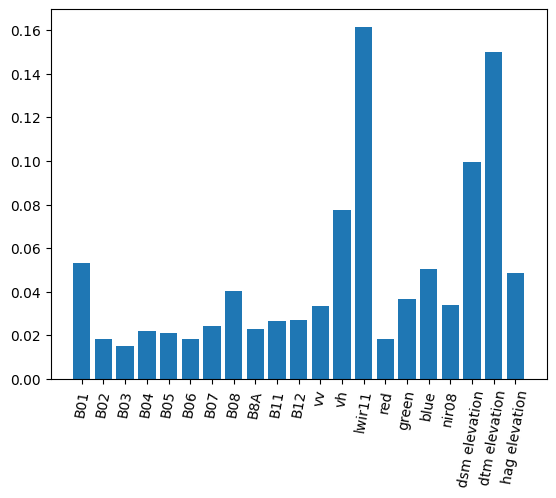

In [320]:
plt.bar(nyc_X.columns, rf.feature_importances_)
plt.xticks(rotation=80)

We now have a model - we can predict greensburg uhi values.

## Greensburg Prediction

In [321]:
greensburg_sentinel_2_summer_data

,B01,B02,B03,B04,B05,B06,B07,B08,B8A,B11,B12
0,1523.5,1450.0,1637.0,1499.5,2087.0,3622.5,4213.0,4103.0,4454.5,3219.0,2324.5
1,1523.5,1450.0,1637.0,1499.5,2087.0,3622.5,4213.0,4103.0,4454.5,3219.0,2324.5
2,1523.5,1366.0,1566.5,1401.0,2087.0,3622.5,4213.0,4360.0,4454.5,3219.0,2324.5
3,1523.5,1476.5,1663.0,1564.5,2271.0,3674.5,4170.5,4212.0,4445.5,3792.5,2690.5
4,1523.5,1596.0,1819.0,1704.0,2271.0,3674.5,4170.5,4277.0,4445.5,3792.5,2690.5
...,...,...,...,...,...,...,...,...,...,...,...
75595,1596.5,1553.0,1731.5,1599.5,2164.5,3226.5,3698.0,4358.0,3965.5,3004.0,2281.0
75596,1596.5,1559.0,1712.0,1547.5,2009.0,2898.5,3290.0,3927.0,3553.5,2779.5,2164.5
75597,1596.5,1795.0,1810.5,1759.5,2009.0,2898.5,3290.0,2723.5,3553.5,2779.5,2164.5
75598,1596.5,1795.0,1810.5,1759.5,2009.0,2898.5,3290.0,2723.5,3553.5,2779.5,2164.5


In [322]:
greensburg_X = pd.DataFrame()
greensburg_X[sentinel_2_bands] = greensburg_proximity_sentinel_2[sentinel_2_bands]
greensburg_X[sentinel_1_all_bands] = greensburg_sentinel_1_rounded_mapped[sentinel_1_all_bands]
greensburg_X[thermal_bands] = greensburg_landsat_thermal_data[thermal_bands]
greensburg_X[non_thermal_bands] = greensburg_non_thermal_data_mapped[non_thermal_bands]
greensburg_X['dsm elevation'] = greensburg_elevation_dsm_mapped['elevation']
greensburg_X['dtm elevation'] = greensburg_natural_elevation_dtm_mapped['elevation']
greensburg_X['hag elevation'] = greensburg_elevation_hag_mapped['elevation']

greensburg_X

,B01,B02,B03,B04,B05,B06,B07,B08,B8A,B11,B12,vv,vh,lwir11,red,green,blue,nir08,dsm elevation,dtm elevation,hag elevation
0,1523.5,1453.5,1653.5,1508.50,2087.0,3703.0,4312.0,4431.75,4589.5,3438.5,2324.5,200.75,88.75,27.03586064000001,0.048875,0.060617,0.034190,0.334023,379.800079,379.806625,9.900
1,1523.5,1453.5,1653.5,1508.50,2087.0,3703.0,4312.0,4431.75,4589.5,3438.5,2324.5,200.75,88.75,27.03586064000001,0.048875,0.060617,0.034190,0.334023,379.800079,379.806625,9.900
2,1523.5,1453.5,1653.5,1508.50,2087.0,3703.0,4312.0,4431.75,4589.5,3438.5,2324.5,200.75,88.75,27.03586064000001,0.048875,0.060617,0.034190,0.334023,379.800079,379.806625,9.900
3,1523.5,1453.5,1653.5,1508.50,2087.0,3703.0,4312.0,4431.75,4589.5,3438.5,2324.5,200.75,88.75,27.03586064000001,0.048875,0.060617,0.034190,0.334023,379.800079,379.806625,9.900
4,1523.5,1453.5,1653.5,1508.50,2087.0,3703.0,4312.0,4431.75,4589.5,3438.5,2324.5,200.75,88.75,26.56417388,0.048875,0.060617,0.034190,0.334023,379.800079,379.806625,9.900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75595,1596.5,1702.5,1810.5,1742.75,2164.5,3003.5,3386.5,3429.75,3553.5,2951.5,2337.5,179.00,90.00,16.087942580000004,0.070394,0.078547,0.045479,0.308736,431.079727,424.131775,24.405
75596,1596.5,1702.5,1810.5,1742.75,2164.5,3003.5,3386.5,3429.75,3553.5,2951.5,2337.5,179.00,90.00,16.087942580000004,0.070394,0.078547,0.045479,0.308736,431.079727,424.131775,24.405
75597,1596.5,1702.5,1810.5,1742.75,2164.5,3003.5,3386.5,3429.75,3553.5,2951.5,2337.5,179.00,90.00,16.169975060000013,0.070394,0.078547,0.045479,0.308736,431.079727,424.131775,24.405
75598,1596.5,1702.5,1810.5,1742.75,2164.5,3003.5,3386.5,3429.75,3553.5,2951.5,2337.5,179.00,90.00,16.169975060000013,0.070394,0.078547,0.045479,0.308736,431.079727,424.131775,24.405


In [323]:
greensburg_uhi_prediction = rf.predict(greensburg_X)

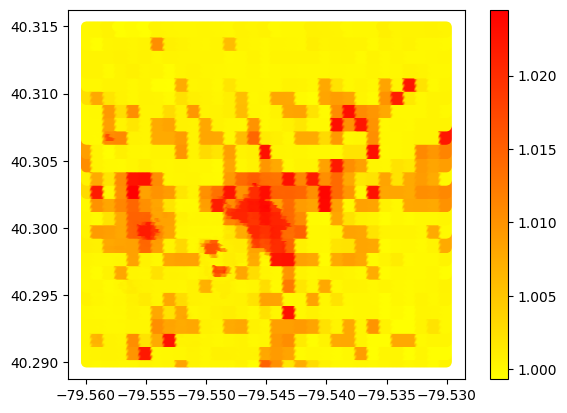

In [324]:
plt.scatter(greensburg_location_df['Longitude'],greensburg_location_df['Latitude'],c=greensburg_uhi_prediction,cmap='autumn_r')
plt.colorbar()

(array([48371.,  3860.,   453., 11822.,  4536.,  1338.,  1137.,   346.,
         1362.,  2375.]),
 array([0.99932124, 1.00183743, 1.00435361, 1.0068698 , 1.00938599,
        1.01190218, 1.01441836, 1.01693455, 1.01945074, 1.02196692,
        1.02448311]),
 <BarContainer object of 10 artists>)

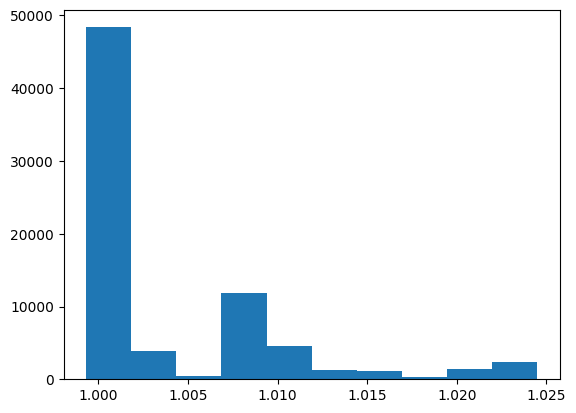

In [328]:
plt.hist(pd.Series(greensburg_uhi_prediction))

In [331]:
greensburg_prediction_df = pd.DataFrame()

greensburg_prediction_df[['Longitude','Latitude']] = greensburg_location_df[['Longitude','Latitude']]

greensburg_prediction_df['UHI Values Prediction'] = greensburg_uhi_prediction

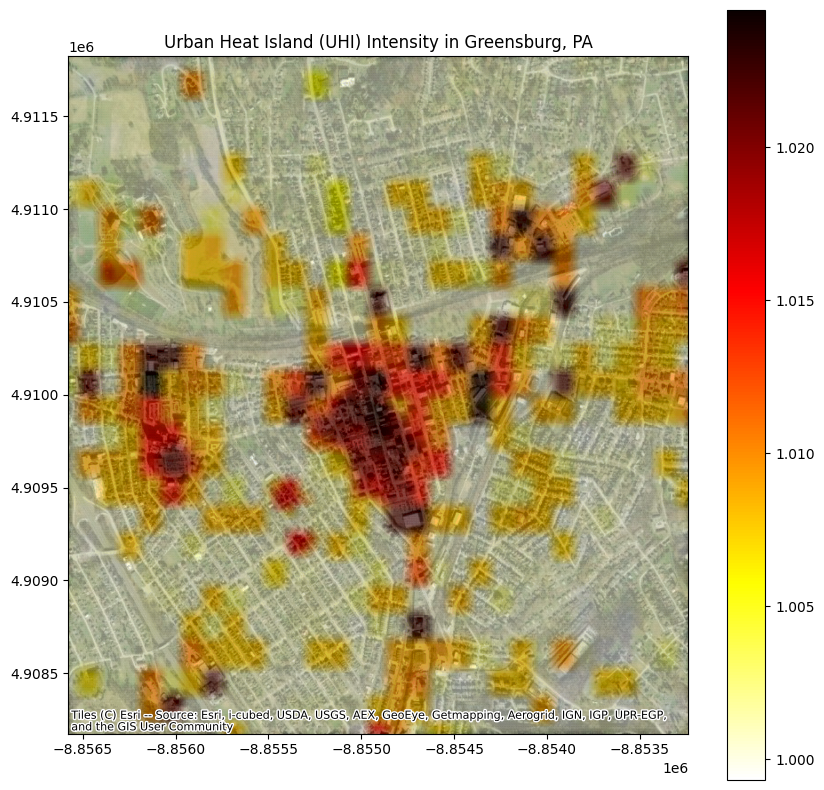

In [343]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import contextily as cx
from shapely.geometry import Point, box

(-79.56,-79.53,40.29,40.315)

# Define bounding box
west, south, east, north = -79.56, 40.29, -79.53, 40.315

# Create GeoDataFrame
uhi_gdf = gpd.GeoDataFrame(
    greensburg_prediction_df,
    geometry=gpd.points_from_xy(greensburg_prediction_df['Longitude'], greensburg_prediction_df['Latitude']),
    crs='EPSG:4326'
)

# Convert to Web Mercator
uhi_gdf = uhi_gdf.to_crs(epsg=3857)

# Convert bbox for plotting
bbox_geom = box(west, south, east, north)
bbox = gpd.GeoSeries([bbox_geom], crs="EPSG:4326").to_crs(epsg=3857)

# Plot
fig, ax = plt.subplots(figsize=(10, 10))

# Plot UHI points colored by value
uhi_gdf.plot(
    ax=ax,
    column='UHI Values Prediction',
    cmap='hot_r',
    legend=True,
    markersize=100,
    alpha=0.025
)

# Set bounds and add basemap
ax.set_xlim(bbox.total_bounds[[0, 2]])
ax.set_ylim(bbox.total_bounds[[1, 3]])
cx.add_basemap(ax, source=cx.providers.Esri.WorldImagery)

plt.title("Urban Heat Island (UHI) Intensity in Greensburg, PA")
plt.show()
